In [1]:
import sys
sys.path.append("..")
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.config as config
import src.svi as svi
import src.variance_swap as vs
importlib.reload(vs)

date = config.SNAPSHOT_DATE
svi_params = pd.read_csv(f"../data/svi_params_{date}.csv", parse_dates=["expiry"])
smiles = pd.read_csv(f"../data/spy_smiles_{date}.csv", parse_dates=["expiry"])
hp = pd.read_csv(f"../data/heston_params_{date}.csv", index_col=0).iloc[:, 0]

print(f"Photo du {date} | {len(svi_params)} maturités | "
      f"Heston : v0 = {hp['v0']:.4f}, θ = {hp['theta']:.4f}, κ = {hp['kappa']:.3f}")

Photo du 2026-10-06 | 26 maturités | Heston : v0 = 0.0174, θ = 0.0593, κ = 1.897


In [2]:
T_test = 1.0
flat = [0.04 * T_test, 0.0, 0.0, 0.0, 0.1]   # SVI avec b = 0 : variance totale constante
kv = vs.var_swap_strike_svi(T_test, flat)
print(f"Vol plate 20 % → strike de variance = {kv:.6f} (attendu : 0.040000) → vol = {np.sqrt(kv):.4%}")

Vol plate 20 % → strike de variance = 0.040000 (attendu : 0.040000) → vol = 20.0000%


In [3]:
rows = []
for _, row in svi_params.iterrows():
    T = row["T"]
    p = row[["a", "b", "rho", "m", "sigma"]].values.astype(float)
    s = smiles[smiles["expiry"] == row["expiry"]]
    rows.append({
        "expiry": row["expiry"].date(),
        "jours": round(T * 365),
        "T": T,
        "vol_ATM": 100 * svi.svi_implied_vol(0.0, T, p),
        "VS_marché": 100 * np.sqrt(vs.var_swap_strike_svi(T, p)),
        "VS_tronqué": 100 * np.sqrt(vs.var_swap_strike_svi(T, p, k_min=s["k"].min(), k_max=s["k"].max())),
        "VS_Heston": 100 * np.sqrt(vs.var_swap_strike_heston(T, hp["v0"], hp["kappa"], hp["theta"])),
    })
vs_table = pd.DataFrame(rows)
vs_table["prime_skew"] = vs_table["VS_marché"] - vs_table["vol_ATM"]

print("Vols en %  (VS = strike d'un variance swap exprimé en vol)")
print(vs_table.drop(columns="T").round(2).to_string(index=False))

Vols en %  (VS = strike d'un variance swap exprimé en vol)
    expiry  jours  vol_ATM  VS_marché  VS_tronqué  VS_Heston  prime_skew
2026-10-13      7     9.01      10.48       10.33      13.47        1.47
2026-10-14      8    10.09      11.59       11.45      13.51        1.50
2026-10-15      9    10.37      12.07       11.84      13.55        1.70
2026-10-16     10    10.62      12.64       12.42      13.59        2.02
2026-10-23     17    10.83      13.06       12.82      13.86        2.23
2026-10-30     24    11.91      14.39       14.23      14.11        2.48
2026-11-06     31    12.54      15.24       15.02      14.35        2.70
2026-11-13     38    12.77      15.64       15.40      14.59        2.87
2026-11-20     45    13.08      16.15       16.02      14.81        3.07
2026-11-30     55    12.83      15.99       15.68      15.12        3.16
2026-12-18     73    13.73      17.42       17.20      15.63        3.69
2026-12-31     86    13.53      17.37       16.76      15.97     

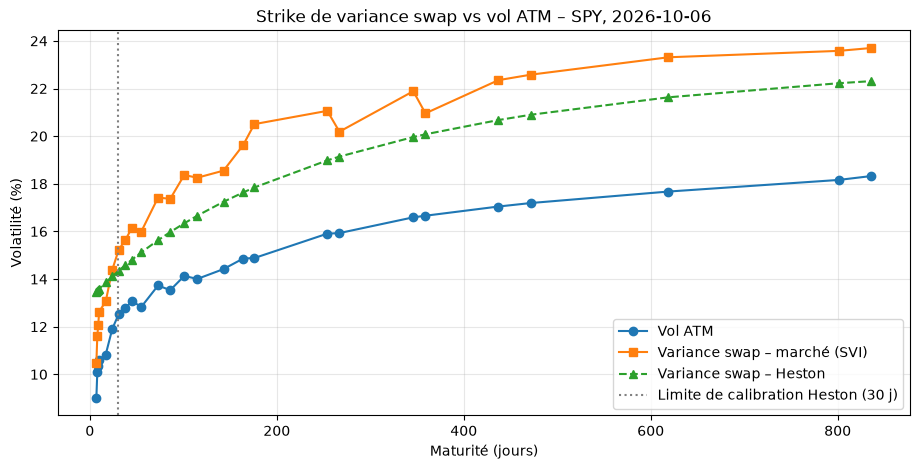

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(vs_table["jours"], vs_table["vol_ATM"], "o-", label="Vol ATM")
ax.plot(vs_table["jours"], vs_table["VS_marché"], "s-", label="Variance swap – marché (SVI)")
ax.plot(vs_table["jours"], vs_table["VS_Heston"], "^--", label="Variance swap – Heston")
ax.axvline(30, color="grey", linestyle=":", label="Limite de calibration Heston (30 j)")
ax.set_xlabel("Maturité (jours)")
ax.set_ylabel("Volatilité (%)")
ax.set_title(f"Strike de variance swap vs vol ATM – SPY, {date}")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig("../figures/variance_swap.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
import yfinance as yf

T30 = 30 / 365
tv = (vs_table["VS_tronqué"] / 100) ** 2 * vs_table["T"]   # variance totale de chaque maturité
near = vs_table[vs_table["T"] <= T30].index[-1]             # maturité juste avant 30 jours
nxt = vs_table[vs_table["T"] > T30].index[0]                # maturité juste après 30 jours
w = (T30 - vs_table.loc[near, "T"]) / (vs_table.loc[nxt, "T"] - vs_table.loc[near, "T"])
tv30 = tv[near] + w * (tv[nxt] - tv[near])
my_vix = 100 * np.sqrt(tv30 / T30)

end = (pd.Timestamp(date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
vix_hist = yf.Ticker("^VIX").history(start=date, end=end)["Close"]

print(f"Mon VIX (SPY, photo du {date}) : {my_vix:.2f}")
if len(vix_hist):
    print(f"VIX officiel (clôture du {date}) : {vix_hist.iloc[0]:.2f}")
else:
    print("VIX officiel pas encore disponible pour cette date (relance après la clôture américaine).")

Mon VIX (SPY, photo du 2026-10-06) : 14.93
VIX officiel (clôture du 2026-10-06) : 15.03
